# VQC Konvergenz-Analyse: Idealer Simulator vs. Noise Models

**Modell:** VQC (RealAmplitudes)  
**Datensätze:** Iris (3 Klassen, 2 Features) + Breast Cancer (2 Klassen, 2 Features)  
**Backends:** AerSimulator (ideal), AerSimulator + IBM Noise Model (ibm_kingston), Synthetisches Noise Model  

Analysiert den Konvergenzverlauf des VQC-Optimierers unter verschiedenen
Rauschbedingungen sowie einen systematischen Fehlerraten-Sweep.


## 0. Imports & Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score

from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

print("Imports OK")
from utils import load_ibm_token


Imports OK


## 1. Datenvorbereitung - identische Pipeline wie `01_iris_simulator`

In [2]:
iris = load_iris()
X = iris.data[:, [0, 2]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler(feature_range=(0, 2 * np.pi))
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (105, 2)  |  Test: (45, 2)


## 2. Hilfsfunktionen

In [3]:
def make_callback(cost_history):
    def callback(weights, value):
        cost_history.append(value)
    return callback

def make_vqc(sampler, maxiter=200, pass_manager=None, num_qubits=2):
    fm = zz_feature_map(feature_dimension=num_qubits, reps=1)
    ansatz = real_amplitudes(num_qubits=num_qubits, reps=2)
    kwargs = dict(
        feature_map=fm,
        ansatz=ansatz,
        optimizer=COBYLA(maxiter=maxiter),
        sampler=sampler,
    )
    if pass_manager is not None:
        kwargs['pass_manager'] = pass_manager
    return kwargs

def make_noisy_backend(error_1q, error_2q):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(error_1q, 1), ['h', 'x', 'u1', 'u2', 'u3', 'sx', 'rz'])
    nm.add_all_qubit_quantum_error(depolarizing_error(error_2q, 2), ['cx', 'cz'])
    backend = AerSimulator(noise_model=nm)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    sampler = SamplerV2.from_backend(backend)
    return sampler, pm

print("Hilfsfunktionen OK")

Hilfsfunktionen OK


## 3. IBM Noise Model laden (ibm_kingston)

In [4]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token=load_ibm_token()
)
hw_backend = service.backend("ibm_kingston")
noise_model_hw = NoiseModel.from_backend(hw_backend)
noisy_backend_hw = AerSimulator(noise_model=noise_model_hw)
pm_hw = generate_preset_pass_manager(optimization_level=1, backend=noisy_backend_hw)
sampler_noise_hw = SamplerV2.from_backend(noisy_backend_hw)

print(f"Noise Model geladen von: {hw_backend.name}")
print(f"Basis-Gates: {noise_model_hw.basis_gates}")

qiskit_runtime_service._discover_account:WARNING:2026-05-24 13:29:32,961: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-24 13:29:36,477: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-24 13:29:36,480: Using instance: open-instance, plan: open


Noise Model geladen von: ibm_kingston
Basis-Gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']


## 4. Konvergenzverlauf: Ideal vs. IBM Noise vs. Synthetisch

Synthetisches Noise Model: 1Q-Fehler 0.1%, 2Q-Fehler 1% (typisches NISQ-Verhältnis).

In [5]:
MAXITER = 200

# --- Ideal ---
cost_ideal = []
vqc_ideal = VQC(**make_vqc(StatevectorSampler(), maxiter=MAXITER),
                callback=make_callback(cost_ideal))
vqc_ideal.fit(X_train_sc, y_train)
acc_ideal = accuracy_score(y_test, vqc_ideal.predict(X_test_sc))
f1_ideal  = f1_score(y_test, vqc_ideal.predict(X_test_sc), average='weighted')
print(f"Ideal        - Accuracy: {acc_ideal:.4f}  F1: {f1_ideal:.4f}  Iter: {len(cost_ideal)}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Ideal        — Accuracy: 0.5111  F1: 0.4099  Iter: 62


In [6]:
# --- IBM Noise Model ---
cost_noise_hw = []
vqc_noise_hw = VQC(**make_vqc(sampler_noise_hw, maxiter=MAXITER, pass_manager=pm_hw),
                   callback=make_callback(cost_noise_hw))
vqc_noise_hw.fit(X_train_sc, y_train)
acc_noise_hw = accuracy_score(y_test, vqc_noise_hw.predict(X_test_sc))
f1_noise_hw  = f1_score(y_test, vqc_noise_hw.predict(X_test_sc), average='weighted')
print(f"IBM Noise    - Accuracy: {acc_noise_hw:.4f}  F1: {f1_noise_hw:.4f}  Iter: {len(cost_noise_hw)}")

IBM Noise    — Accuracy: 0.3778  F1: 0.3203  Iter: 67


In [7]:
# --- Synthetisches Noise Model (1Q: 0.1%, 2Q: 1%) ---
cost_noise_syn = []
sampler_syn, pm_syn = make_noisy_backend(0.001, 0.01)
vqc_noise_syn = VQC(**make_vqc(sampler_syn, maxiter=MAXITER, pass_manager=pm_syn),
                    callback=make_callback(cost_noise_syn))
vqc_noise_syn.fit(X_train_sc, y_train)
acc_noise_syn = accuracy_score(y_test, vqc_noise_syn.predict(X_test_sc))
f1_noise_syn  = f1_score(y_test, vqc_noise_syn.predict(X_test_sc), average='weighted')
print(f"Synthetisch  - Accuracy: {acc_noise_syn:.4f}  F1: {f1_noise_syn:.4f}  Iter: {len(cost_noise_syn)}")

Synthetisch  — Accuracy: 0.5556  F1: 0.4254  Iter: 65


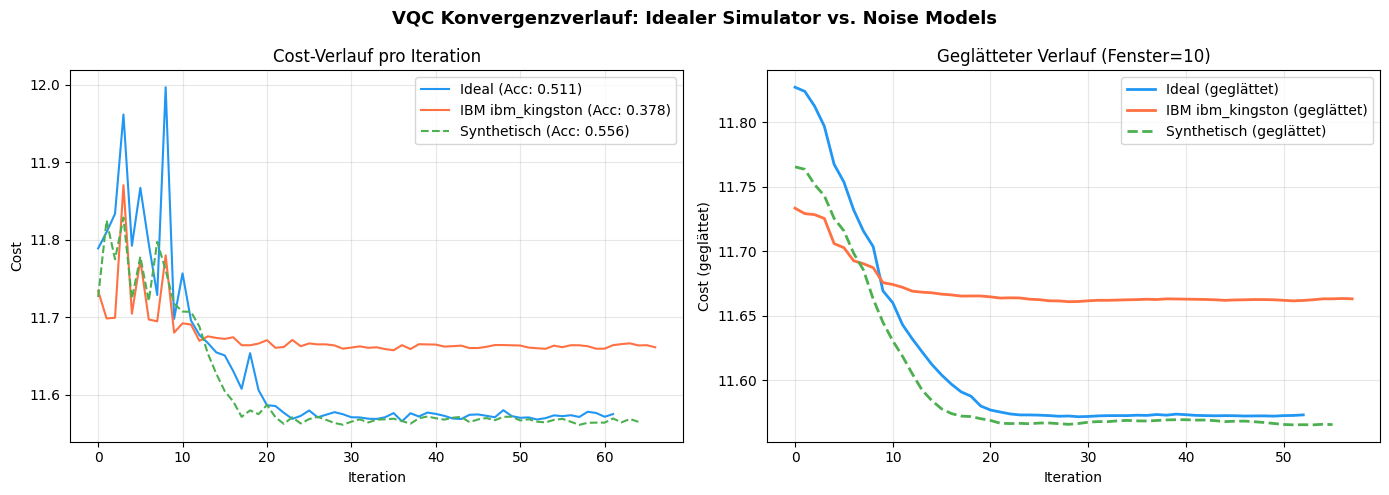

Gespeichert: vqc_konvergenz.png


In [8]:
# Konvergenzplot
def smooth(data, w=10):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VQC Konvergenzverlauf: Idealer Simulator vs. Noise Models', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(cost_ideal,     label=f'Ideal (Acc: {acc_ideal:.3f})',           color='#2196F3', linewidth=1.5)
ax1.plot(cost_noise_hw,  label=f'IBM ibm_kingston (Acc: {acc_noise_hw:.3f})', color='#FF7043', linewidth=1.5)
ax1.plot(cost_noise_syn, label=f'Synthetisch (Acc: {acc_noise_syn:.3f})', color='#4CAF50', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Iteration'); ax1.set_ylabel('Cost')
ax1.set_title('Cost-Verlauf pro Iteration')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
w = 10
ax2.plot(smooth(cost_ideal, w),     label='Ideal (geglättet)',           color='#2196F3', linewidth=2)
ax2.plot(smooth(cost_noise_hw, w),  label='IBM ibm_kingston (geglättet)', color='#FF7043', linewidth=2)
ax2.plot(smooth(cost_noise_syn, w), label='Synthetisch (geglättet)',     color='#4CAF50', linewidth=2, linestyle='--')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Cost (geglättet)')
ax2.set_title(f'Geglätteter Verlauf (Fenster={w})')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Ergebnisse/vqc_konvergenz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: vqc_konvergenz.png")

## 5. Fehlerraten-Sweep - Ab wann bricht VQC ein?

2Q-Fehlerraten: 0.1%, 0.3%, 0.5%, 1%, 2%, 5%  
1Q-Fehlerrate jeweils 10x kleiner (typisches Hardware-Verhältnis).  
Jede Konfiguration: COBYLA, 100 Iterationen.

In [9]:
ERROR_RATES_2Q = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]
SWEEP_MAXITER  = 100

sweep_results = []

for err_2q in ERROR_RATES_2Q:
    err_1q = err_2q / 10
    print(f"2Q-Fehlerrate: {err_2q*100:.1f}%  |  1Q: {err_1q*100:.2f}% ...", end=' ', flush=True)

    sampler_s, pm_s = make_noisy_backend(err_1q, err_2q)
    vqc_s = VQC(**make_vqc(sampler_s, maxiter=SWEEP_MAXITER, pass_manager=pm_s))
    vqc_s.fit(X_train_sc, y_train)

    y_pred_s = vqc_s.predict(X_test_sc)
    acc_s = accuracy_score(y_test, y_pred_s)
    f1_s  = f1_score(y_test, y_pred_s, average='weighted')

    print(f"Accuracy: {acc_s:.4f}  F1: {f1_s:.4f}")
    sweep_results.append({'err_2q': err_2q, 'err_1q': err_1q, 'accuracy': acc_s, 'f1': f1_s})

print("\nSweep abgeschlossen.")

2Q-Fehlerrate: 0.1%  |  1Q: 0.01% ... Accuracy: 0.3556  F1: 0.2836
2Q-Fehlerrate: 0.3%  |  1Q: 0.03% ... Accuracy: 0.3556  F1: 0.2849
2Q-Fehlerrate: 0.5%  |  1Q: 0.05% ... Accuracy: 0.3333  F1: 0.2641
2Q-Fehlerrate: 1.0%  |  1Q: 0.10% ... Accuracy: 0.4667  F1: 0.3732
2Q-Fehlerrate: 2.0%  |  1Q: 0.20% ... Accuracy: 0.4000  F1: 0.3191
2Q-Fehlerrate: 5.0%  |  1Q: 0.50% ... Accuracy: 0.4667  F1: 0.3810

Sweep abgeschlossen.


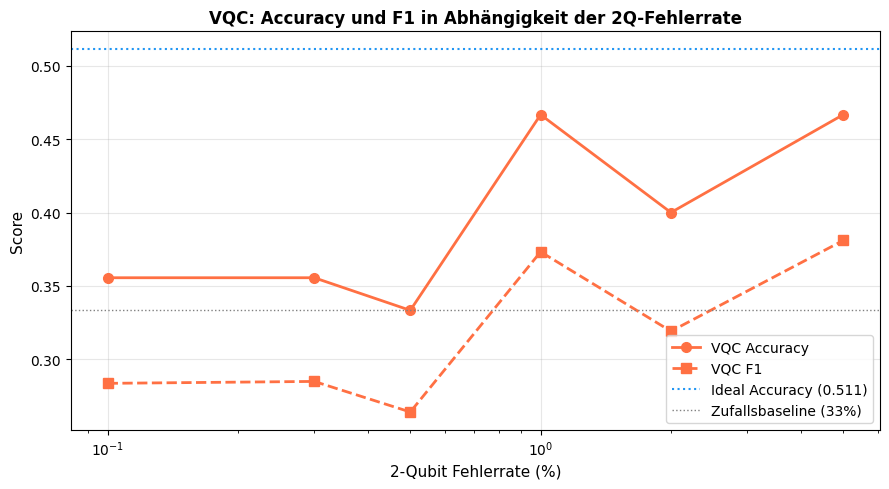

Gespeichert: vqc_fehlerrate_sweep.png

 err_2q_pct  accuracy       f1
        0.1  0.355556 0.283596
        0.3  0.355556 0.284900
        0.5  0.333333 0.264069
        1.0  0.466667 0.373219
        2.0  0.400000 0.319088
        5.0  0.466667 0.380952


In [10]:
import pandas as pd

df_sweep = pd.DataFrame(sweep_results)
df_sweep['err_2q_pct'] = df_sweep['err_2q'] * 100

# Referenzlinie: Idealer Simulator
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_sweep['err_2q_pct'], df_sweep['accuracy'],
        marker='o', color='#FF7043', linewidth=2, markersize=7, label='VQC Accuracy')
ax.plot(df_sweep['err_2q_pct'], df_sweep['f1'],
        marker='s', color='#FF7043', linewidth=2, markersize=7, linestyle='--', label='VQC F1')
ax.axhline(acc_ideal, color='#2196F3', linestyle=':', linewidth=1.5, label=f'Ideal Accuracy ({acc_ideal:.3f})')
ax.axhline(1/3, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline (33%)')

ax.set_xscale('log')
ax.set_xlabel('2-Qubit Fehlerrate (%)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('VQC: Accuracy und F1 in Abhängigkeit der 2Q-Fehlerrate', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Ergebnisse/vqc_fehlerrate_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: vqc_fehlerrate_sweep.png")

print()
print(df_sweep[['err_2q_pct', 'accuracy', 'f1']].to_string(index=False))

## 6. Zusammenfassung

In [11]:
print("=" * 60)
print(f"{'Bedingung':<35} {'Accuracy':>10} {'F1':>8}")
print("-" * 60)
print(f"{'Idealer Simulator':<35} {acc_ideal:>10.4f} {f1_ideal:>8.4f}")
print(f"{'Noise Model (ibm_kingston)':<35} {acc_noise_hw:>10.4f} {f1_noise_hw:>8.4f}")
print(f"{'Noise synthetisch (1%/0.1%)':<35} {acc_noise_syn:>10.4f} {f1_noise_syn:>8.4f}")
print("=" * 60)
print()
print("Fehlerraten-Sweep (2Q-Fehlerrate → Accuracy):")
for r in sweep_results:
    print(f"  {r['err_2q']*100:.1f}%  →  {r['accuracy']:.4f}")

Bedingung                             Accuracy       F1
------------------------------------------------------------
Idealer Simulator                       0.5111   0.4099
Noise Model (ibm_kingston)              0.3778   0.3203
Noise synthetisch (1%/0.1%)             0.5556   0.4254

Fehlerraten-Sweep (2Q-Fehlerrate → Accuracy):
  0.1%  →  0.3556
  0.3%  →  0.3556
  0.5%  →  0.3333
  1.0%  →  0.4667
  2.0%  →  0.4000
  5.0%  →  0.4667


## 7. Breast Cancer - Datenvorbereitung

Identische Pipeline wie `05_breast_cancer_simulator` (PCA auf 2 Komponenten).

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

bc = load_breast_cancer()
X_bc = bc.data
y_bc = bc.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc
)

pca = PCA(n_components=2, random_state=42)
X_train_bc_pca = pca.fit_transform(X_train_bc)
X_test_bc_pca  = pca.transform(X_test_bc)

from sklearn.preprocessing import MinMaxScaler as MMS
scaler_bc = MMS(feature_range=(0, 2 * np.pi))
X_train_bc_sc = scaler_bc.fit_transform(X_train_bc_pca)
X_test_bc_sc  = scaler_bc.transform(X_test_bc_pca)

print(f"Erklärte Varianz: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Train: {X_train_bc_sc.shape}  |  Test: {X_test_bc_sc.shape}")

Erklärte Varianz: 99.93%
Train: (398, 2)  |  Test: (171, 2)


## 8. VQC Breast Cancer - Ideal vs. IBM Noise vs. Synthetisch

In [13]:
# --- Ideal ---
cost_bc_ideal = []
vqc_bc_ideal = VQC(**make_vqc(StatevectorSampler(), maxiter=MAXITER),
                   callback=make_callback(cost_bc_ideal))
vqc_bc_ideal.fit(X_train_bc_sc, y_train_bc)
acc_bc_ideal = accuracy_score(y_test_bc, vqc_bc_ideal.predict(X_test_bc_sc))
f1_bc_ideal  = f1_score(y_test_bc, vqc_bc_ideal.predict(X_test_bc_sc), average='binary')
print(f"Ideal        - Accuracy: {acc_bc_ideal:.4f}  F1: {f1_bc_ideal:.4f}  Iter: {len(cost_bc_ideal)}")

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Ideal        — Accuracy: 0.8655  F1: 0.9067  Iter: 63


In [14]:
# --- IBM Noise Model ---
cost_bc_noise_hw = []
vqc_bc_noise_hw = VQC(**make_vqc(sampler_noise_hw, maxiter=MAXITER, pass_manager=pm_hw),
                      callback=make_callback(cost_bc_noise_hw))
vqc_bc_noise_hw.fit(X_train_bc_sc, y_train_bc)
acc_bc_noise_hw = accuracy_score(y_test_bc, vqc_bc_noise_hw.predict(X_test_bc_sc))
f1_bc_noise_hw  = f1_score(y_test_bc, vqc_bc_noise_hw.predict(X_test_bc_sc), average='binary')
print(f"IBM Noise    - Accuracy: {acc_bc_noise_hw:.4f}  F1: {f1_bc_noise_hw:.4f}  Iter: {len(cost_bc_noise_hw)}")

IBM Noise    — Accuracy: 0.8655  F1: 0.9083  Iter: 64


In [15]:
# --- Synthetisches Noise Model ---
cost_bc_noise_syn = []
sampler_bc_syn, pm_bc_syn = make_noisy_backend(0.001, 0.01)
vqc_bc_noise_syn = VQC(**make_vqc(sampler_bc_syn, maxiter=MAXITER, pass_manager=pm_bc_syn),
                       callback=make_callback(cost_bc_noise_syn))
vqc_bc_noise_syn.fit(X_train_bc_sc, y_train_bc)
acc_bc_noise_syn = accuracy_score(y_test_bc, vqc_bc_noise_syn.predict(X_test_bc_sc))
f1_bc_noise_syn  = f1_score(y_test_bc, vqc_bc_noise_syn.predict(X_test_bc_sc), average='binary')
print(f"Synthetisch  - Accuracy: {acc_bc_noise_syn:.4f}  F1: {f1_bc_noise_syn:.4f}  Iter: {len(cost_bc_noise_syn)}")

Synthetisch  — Accuracy: 0.8538  F1: 0.8870  Iter: 62


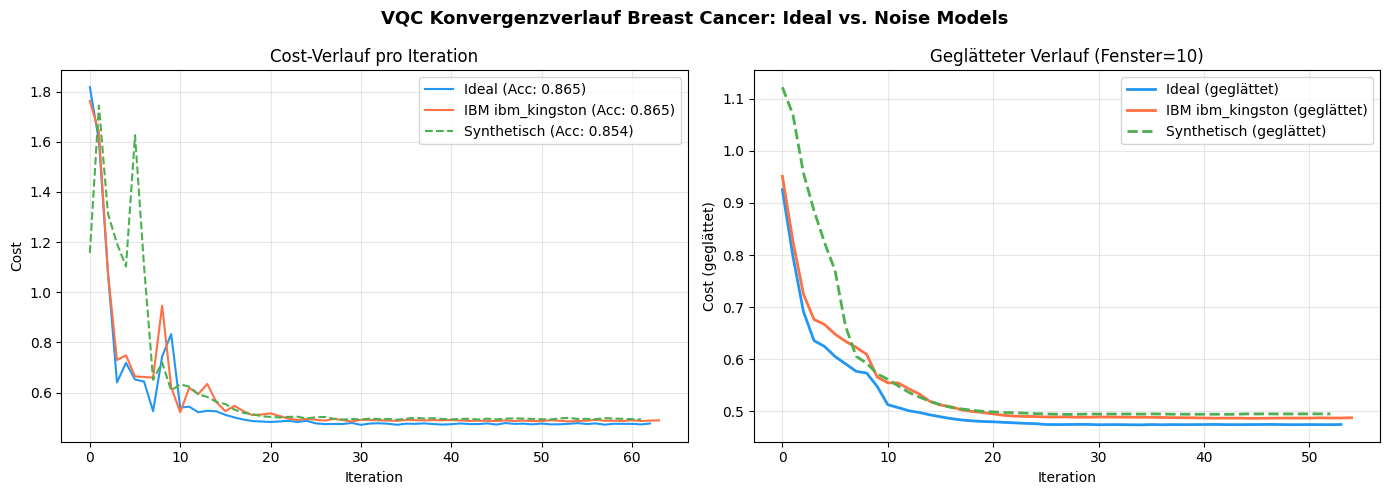

Gespeichert: vqc_konvergenz_bc.png


In [16]:
# Konvergenzplot BC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('VQC Konvergenzverlauf Breast Cancer: Ideal vs. Noise Models', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(cost_bc_ideal,     label=f'Ideal (Acc: {acc_bc_ideal:.3f})',           color='#2196F3', linewidth=1.5)
ax1.plot(cost_bc_noise_hw,  label=f'IBM ibm_kingston (Acc: {acc_bc_noise_hw:.3f})', color='#FF7043', linewidth=1.5)
ax1.plot(cost_bc_noise_syn, label=f'Synthetisch (Acc: {acc_bc_noise_syn:.3f})', color='#4CAF50', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Iteration'); ax1.set_ylabel('Cost')
ax1.set_title('Cost-Verlauf pro Iteration')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
w = 10
if len(cost_bc_ideal) >= w:
    ax2.plot(smooth(cost_bc_ideal, w),     label='Ideal (geglättet)',           color='#2196F3', linewidth=2)
if len(cost_bc_noise_hw) >= w:
    ax2.plot(smooth(cost_bc_noise_hw, w),  label='IBM ibm_kingston (geglättet)', color='#FF7043', linewidth=2)
if len(cost_bc_noise_syn) >= w:
    ax2.plot(smooth(cost_bc_noise_syn, w), label='Synthetisch (geglättet)',     color='#4CAF50', linewidth=2, linestyle='--')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('Cost (geglättet)')
ax2.set_title(f'Geglätteter Verlauf (Fenster={w})')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Ergebnisse/vqc_konvergenz_bc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: vqc_konvergenz_bc.png")

## 9. Fehlerraten-Sweep Breast Cancer

In [18]:
sweep_results_bc = []

for err_2q in ERROR_RATES_2Q:
    err_1q = err_2q / 10
    print(f"2Q-Fehlerrate: {err_2q*100:.1f}%  |  1Q: {err_1q*100:.2f}% ...", end=' ', flush=True)

    sampler_s, pm_s = make_noisy_backend(err_1q, err_2q)
    vqc_s = VQC(**make_vqc(sampler_s, maxiter=SWEEP_MAXITER, pass_manager=pm_s))
    vqc_s.fit(X_train_bc_sc, y_train_bc)
    y_pred_s = vqc_s.predict(X_test_bc_sc)
    acc_s = accuracy_score(y_test_bc, y_pred_s)
    f1_s  = f1_score(y_test_bc, y_pred_s, average='binary')

    print(f"Accuracy: {acc_s:.4f}  F1: {f1_s:.4f}")
    sweep_results_bc.append({'err_2q': err_2q, 'err_1q': err_1q, 'accuracy': acc_s, 'f1': f1_s})

print("Sweep BC abgeschlossen.")

2Q-Fehlerrate: 0.1%  |  1Q: 0.01% ... Accuracy: 0.8596  F1: 0.8966
2Q-Fehlerrate: 0.3%  |  1Q: 0.03% ... Accuracy: 0.8538  F1: 0.8908
2Q-Fehlerrate: 0.5%  |  1Q: 0.05% ... Accuracy: 0.8538  F1: 0.8918
2Q-Fehlerrate: 1.0%  |  1Q: 0.10% ... Accuracy: 0.8830  F1: 0.9107
2Q-Fehlerrate: 2.0%  |  1Q: 0.20% ... Accuracy: 0.8596  F1: 0.8957
2Q-Fehlerrate: 5.0%  |  1Q: 0.50% ... Accuracy: 0.8480  F1: 0.8870
Sweep BC abgeschlossen.


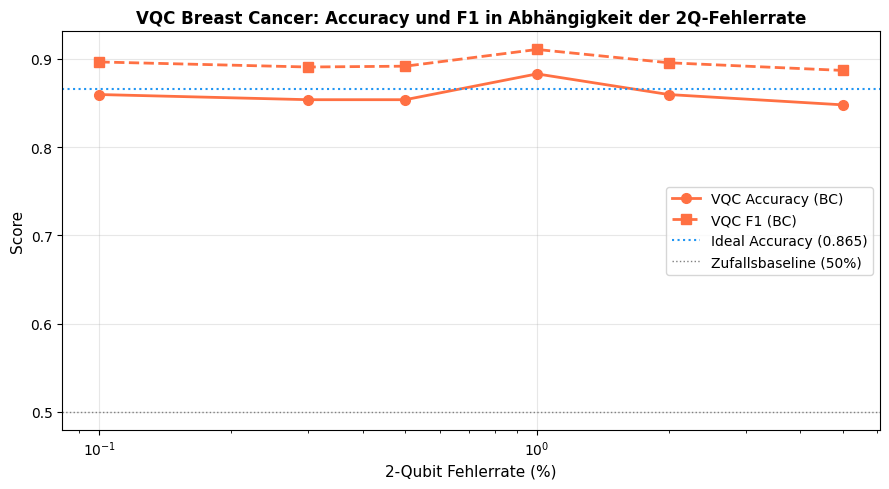

Gespeichert: vqc_fehlerrate_sweep_bc.png

 err_2q_pct  accuracy       f1
        0.1  0.859649 0.896552
        0.3  0.853801 0.890830
        0.5  0.853801 0.891775
        1.0  0.883041 0.910714
        2.0  0.859649 0.895652
        5.0  0.847953 0.886957


In [19]:
df_sweep_bc = pd.DataFrame(sweep_results_bc)
df_sweep_bc['err_2q_pct'] = df_sweep_bc['err_2q'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sweep_bc['err_2q_pct'], df_sweep_bc['accuracy'],
        marker='o', color='#FF7043', linewidth=2, markersize=7, label='VQC Accuracy (BC)')
ax.plot(df_sweep_bc['err_2q_pct'], df_sweep_bc['f1'],
        marker='s', color='#FF7043', linewidth=2, markersize=7, linestyle='--', label='VQC F1 (BC)')
ax.axhline(acc_bc_ideal, color='#2196F3', linestyle=':', linewidth=1.5, label=f'Ideal Accuracy ({acc_bc_ideal:.3f})')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Zufallsbaseline (50%)')
ax.set_xscale('log')
ax.set_xlabel('2-Qubit Fehlerrate (%)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('VQC Breast Cancer: Accuracy und F1 in Abhängigkeit der 2Q-Fehlerrate', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Ergebnisse/vqc_fehlerrate_sweep_bc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert: vqc_fehlerrate_sweep_bc.png")
print()
print(df_sweep_bc[['err_2q_pct', 'accuracy', 'f1']].to_string(index=False))